# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

Develop a predictive model to estimate used car prices using a diverse set of independent variables (features) such as make, model, year, mileage, condition, and other relevant attributes. Perform feature selection and importance analysis to identify the most significant factors influencing price variations. Utilize techniques like correlation analysis, feature importance ranking, and possibly dimensionality reduction methods to determine the key drivers of used car prices. The model's performance will be evaluated using appropriate regression metrics, and the results will be interpreted to provide actionable insights for the business.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [48]:
from sklearn import set_config
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

set_config(display="diagram")

from warnings import filterwarnings 
filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import plotly.express as px

In [49]:
## Load and Inspect the dataSet

In [50]:
vehicles = pd.read_csv('data/vehicles.csv')

In [53]:
vehicles.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [52]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [6]:
vehicles.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [7]:
vehicles.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


Missing values, null values, and all data issues addressed in next section

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [8]:
# Drop the unnecessary columns
vehicles1 = vehicles.drop(columns=['id', 'VIN', 'drive', 'size'])
vehicles1.tail()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,paint_color,state
426875,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,sedan,NaN,wy
426876,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,sedan,red,wy
426877,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,hatchback,white,wy
426878,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,sedan,silver,wy
426879,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,coupe,NaN,wy


In [9]:
# Convert the datatypes and Re-Inspect the dataset
vehicles1 = vehicles1.convert_dtypes()
vehicles1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   region        426880 non-null  string
 1   price         426880 non-null  Int64 
 2   year          425675 non-null  Int64 
 3   manufacturer  409234 non-null  string
 4   model         421603 non-null  string
 5   condition     252776 non-null  string
 6   cylinders     249202 non-null  string
 7   fuel          423867 non-null  string
 8   odometer      422480 non-null  Int64 
 9   title_status  418638 non-null  string
 10  transmission  424324 non-null  string
 11  type          334022 non-null  string
 12  paint_color   296677 non-null  string
 13  state         426880 non-null  string
dtypes: Int64(3), string(11)
memory usage: 46.8 MB


In [10]:
# Descriptive statistics
vehicles1.describe()

,price,year,odometer
count,426880.0,425675.0,422480.0
mean,75199.033187,2011.235191,98043.331443
std,12182282.173598,9.45212,213881.500798
min,0.0,1900.0,0.0
25%,5900.0,2008.0,37704.0
50%,13950.0,2013.0,85548.0
75%,26485.75,2017.0,133542.5
max,3736928711.0,2022.0,10000000.0


In [11]:
# Describe string columns
vehicles1.describe(include = ['string'])

,region,manufacturer,model,condition,cylinders,fuel,title_status,transmission,type,paint_color,state
count,426880,409234,421603,252776,249202,423867,418638,424324,334022,296677,426880
unique,404,42,29649,6,8,5,6,3,13,12,51
top,columbus,ford,f-150,good,6 cylinders,gas,clean,automatic,sedan,white,ca
freq,3608,70985,8009,121456,94169,356209,405117,336524,87056,79285,50614


In [12]:
# Check the null values
vehicles1.isnull().sum()

region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
type             92858
paint_color     130203
state                0
dtype: int64

In [13]:
#Drop the rows where price is 0
vehicles1.drop(vehicles1[vehicles1['price'] == 0].index, inplace=True)
vehicles2 = vehicles1

#Drop the rows where price is less than 1000
vehicles2 = vehicles1.drop(vehicles1[vehicles1['price'] <1000].index)
vehicles2 = vehicles1.drop(vehicles1[vehicles1['odometer'] <100].index)
vehicles2.info()

column_zero_counts2 = (vehicles2 == 0).sum()
print(column_zero_counts2)

<class 'pandas.core.frame.DataFrame'>
Index: 388899 entries, 0 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   region        388899 non-null  string
 1   price         388899 non-null  Int64 
 2   year          387847 non-null  Int64 
 3   manufacturer  373519 non-null  string
 4   model         384313 non-null  string
 5   condition     240169 non-null  string
 6   cylinders     231144 non-null  string
 7   fuel          386418 non-null  string
 8   odometer      386609 non-null  Int64 
 9   title_status  381663 non-null  string
 10  transmission  387132 non-null  string
 11  type          305007 non-null  string
 12  paint_color   274528 non-null  string
 13  state         388899 non-null  string
dtypes: Int64(3), string(11)
memory usage: 45.6 MB
region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer   

In [14]:
#Drop rows where all these columns have null values
vehicles3 = vehicles2.dropna(subset=['year','manufacturer','model','condition','cylinders','fuel','odometer','title_status','transmission','type','paint_color'], how='all')
vehicles3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 388837 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   region        388837 non-null  string
 1   price         388837 non-null  Int64 
 2   year          387847 non-null  Int64 
 3   manufacturer  373519 non-null  string
 4   model         384313 non-null  string
 5   condition     240169 non-null  string
 6   cylinders     231144 non-null  string
 7   fuel          386418 non-null  string
 8   odometer      386609 non-null  Int64 
 9   title_status  381663 non-null  string
 10  transmission  387132 non-null  string
 11  type          305007 non-null  string
 12  paint_color   274528 non-null  string
 13  state         388837 non-null  string
dtypes: Int64(3), string(11)
memory usage: 45.6 MB


In [15]:
#remove outlines from price, year and odometer columns

def remove_outliers_iqr(df, column_name):
    """Removes outliers from the specified column using the IQR method."""
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

#remove outlines from price and odometer columns
vehicles3 = remove_outliers_iqr(vehicles3, 'price')
vehicles3 = remove_outliers_iqr(vehicles3, 'odometer')
vehicles3 = remove_outliers_iqr(vehicles3, 'year')


In [16]:
#Impute the missing values
#region	manufacturer	model	condition	cylinders	fuel	title_status	transmission	drive	size	type	paint_color	state
#Manufacturer
vehicles3['manufacturer'].fillna(vehicles3['manufacturer'].mode()[0], inplace=True)
vehicles3['model'].fillna(vehicles3['model'].mode()[0], inplace=True)
vehicles3['condition'].fillna(vehicles3['condition'].mode()[0], inplace=True)
vehicles3['cylinders'].fillna(vehicles3['cylinders'].mode()[0], inplace=True)
vehicles3['fuel'].fillna(vehicles3['fuel'].mode()[0], inplace=True)
vehicles3['title_status'].fillna(vehicles3['title_status'].mode()[0], inplace=True)

In [17]:
# Dataframe for numeric variables
vehicles4 = vehicles3[['price', 'year', 'odometer']]
vehicles4.head()

,price,year,odometer
27,33590,2014,57923
28,22590,2010,71229
29,39590,2020,19160
30,30990,2017,41124
31,15000,2013,128000


In [18]:
#Compute the covariance for the numeric columns 
vehicles4.cov()

,price,year,odometer
price,1.631661e+08,41140.320914,-4.191371e+08
year,4.114032e+04,29.839665,-2.187257e+05
odometer,-4.191371e+08,-218725.665565,3.639888e+09


In [19]:
#Compute the Correlation Matrix 
vehicles4.corr()

,price,year,odometer
price,1.000000,0.589598,-0.543873
year,0.589598,1.000000,-0.663680
odometer,-0.543873,-0.663680,1.000000


Correlation Matrix has ones along the diagonal showing that year and odometer are strongly correlated to the price of the car

In [20]:
### Visualization

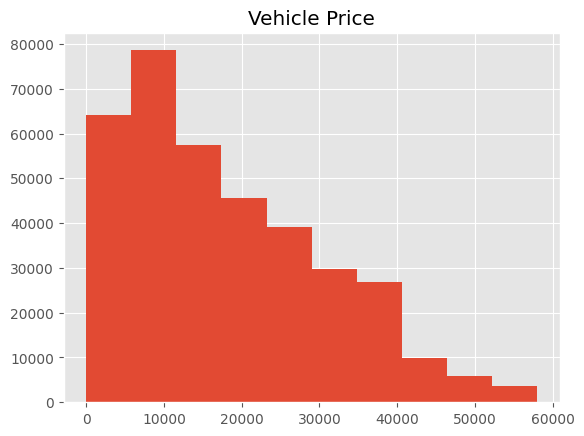

<Figure size 600x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [71]:
# Visualize the price column
vehicles3.price.hist()
plt.title('Vehicle Price')
plt.figure(figsize=(6, 5))
plt.tight_layout()
plt.show()
# Save the plot
plt.savefig('images/vehicles_price.png')
plt.savefig('images/vehicles_price.jpg')

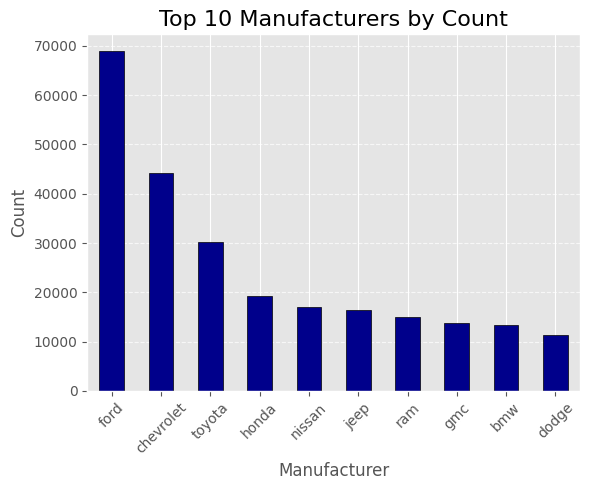

In [65]:
# Inspect the manufacturer column and visualize
top_manufacturers = vehicles3.groupby('manufacturer')['manufacturer'].size().nlargest(10)

plt.figure(figsize=(6, 5))
top_manufacturers.plot(kind='bar', color='darkblue', edgecolor='black')
plt.title('Top 10 Manufacturers by Count', fontsize=16)
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

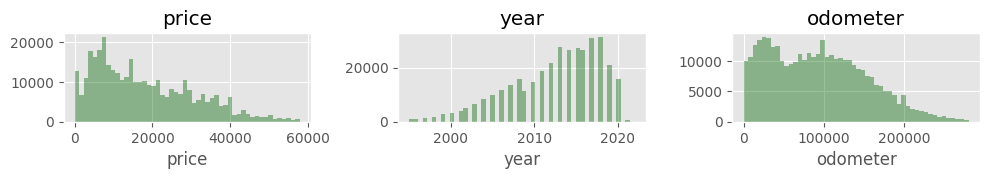

In [23]:
#select all quantitative columns for checking the spread
plt.style.use('ggplot')
numeric_columns = vehicles3.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10,15))

for i, variable in enumerate(numeric_columns):
                     plt.subplot(10,3,i+1)
                       
                     sns.distplot(vehicles3[variable],kde=False,color='darkgreen')
                     plt.tight_layout()
                     plt.title(variable)

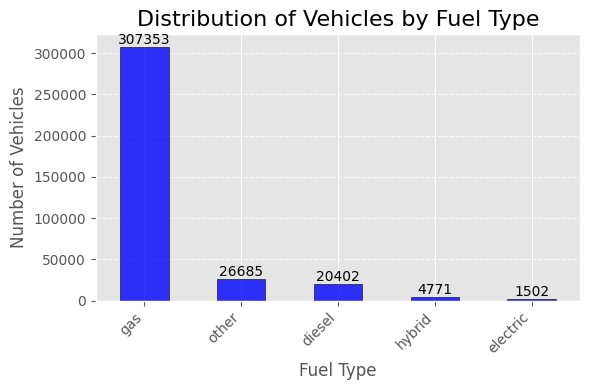

In [72]:
# Visualize vehicles by Fuel type

# Count the occurrences of each fuel type
fuel_counts = vehicles3['fuel'].value_counts()

# Create a bar plot
plt.figure(figsize=(6, 4))
fuel_counts.plot(kind='bar', edgecolor='black', alpha=0.8, color='blue')

# Customize the plot
plt.title('Distribution of Vehicles by Fuel Type', fontsize=16)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, v in enumerate(fuel_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

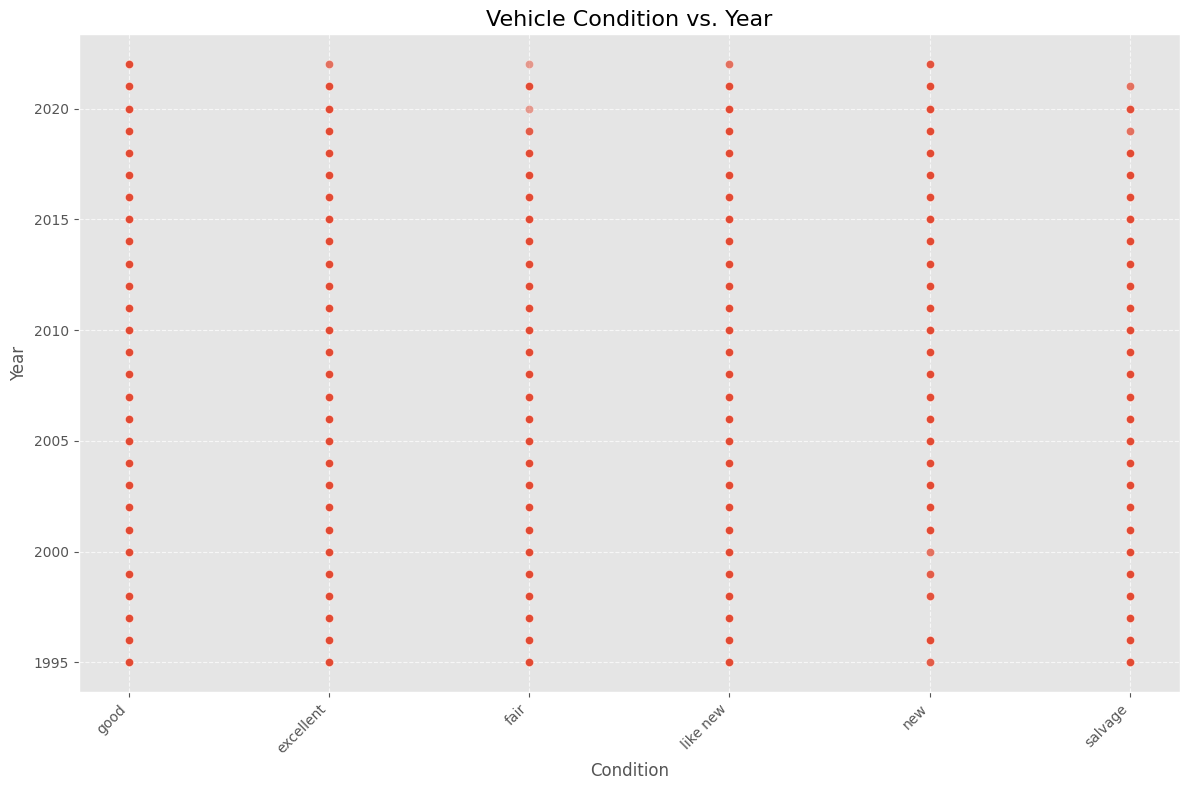

In [25]:
# Create the scatter plot for Vehicle Condition vs. Year
plt.figure(figsize=(12, 8))
sns.scatterplot(data=vehicles3, x='condition', y='year', alpha=0.5)

# Customize the plot
plt.title('Vehicle Condition vs. Year', fontsize=16)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Rotate x-axis labels if they overlap
plt.xticks(rotation=45, ha='right')

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

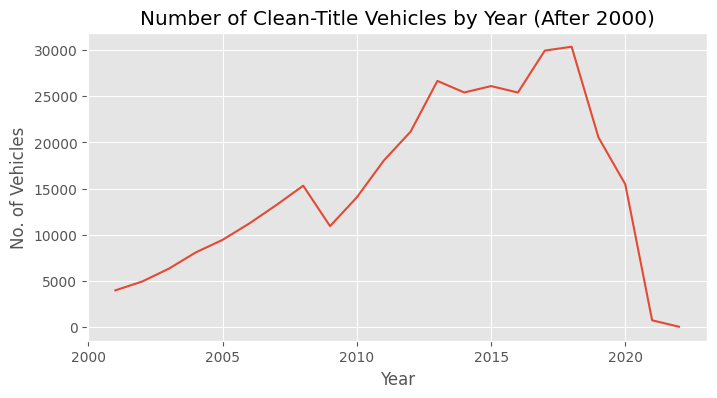

In [26]:
vehicles3_title_status = vehicles3[(vehicles3['title_status'] == 'clean') & (vehicles3['year'] > 2000)].groupby('year').size().reset_index(name='count')

plt.figure(figsize=(8, 4))
sns.lineplot(data=vehicles3_title_status, x='year', y='count')
plt.title('Number of Clean-Title Vehicles by Year (After 2000)')
plt.xlabel('Year')
plt.ylabel('No. of Vehicles')
plt.show()

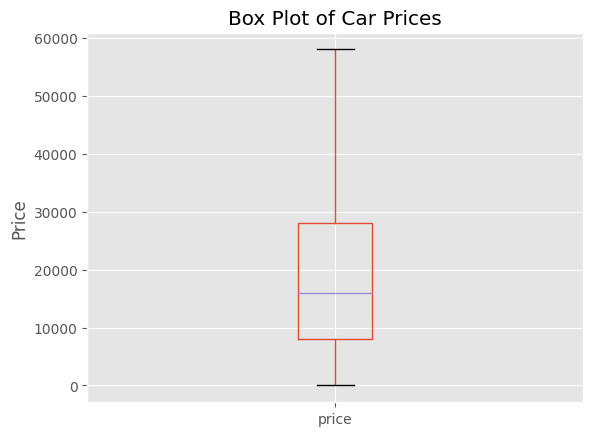

In [27]:
# Plot of Car Prices
sample_vehicles4 = vehicles4.sample(2000) 
sample_vehicles4.boxplot(column='price')
plt.title('Box Plot of Car Prices')
plt.ylabel('Price')
plt.show()

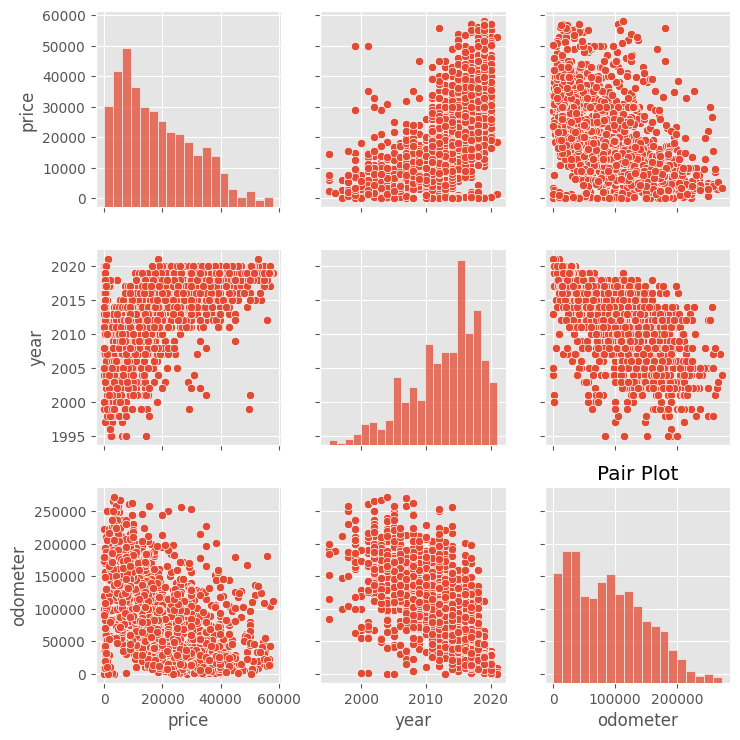

In [28]:
#Pair Plot
sns.pairplot(sample_vehicles4)
plt.title('Pair Plot')
plt.tight_layout()
plt.show()
#plt.savefig('/content/sample_data/pairplot1.png')

Text(0.5, 1.0, 'Price vs Condition Plot')

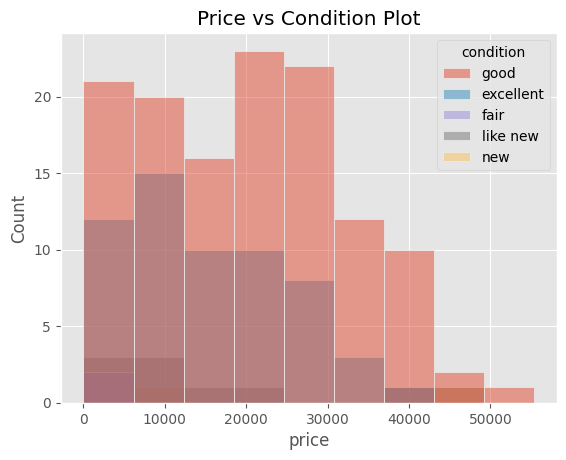

In [60]:
# Histplot for price vs condition
sample_vehicles5 = vehicles3.sample(200) 
sns.histplot(data =sample_vehicles5, x='price', hue='condition')
plt.title('Price vs Condition Plot')

Text(0.5, 1.0, 'Odometer vs Condition Plot')

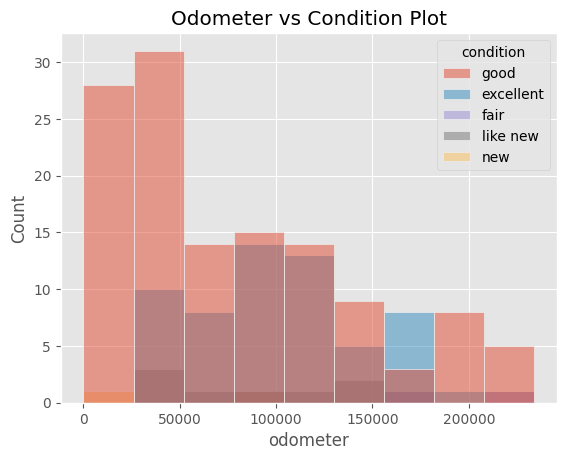

In [61]:
# # Histplot for odometer vs condition
sns.histplot(data =sample_vehicles5, x='odometer', hue='condition', color = (1, 0, 0))
plt.title('Odometer vs Condition Plot')

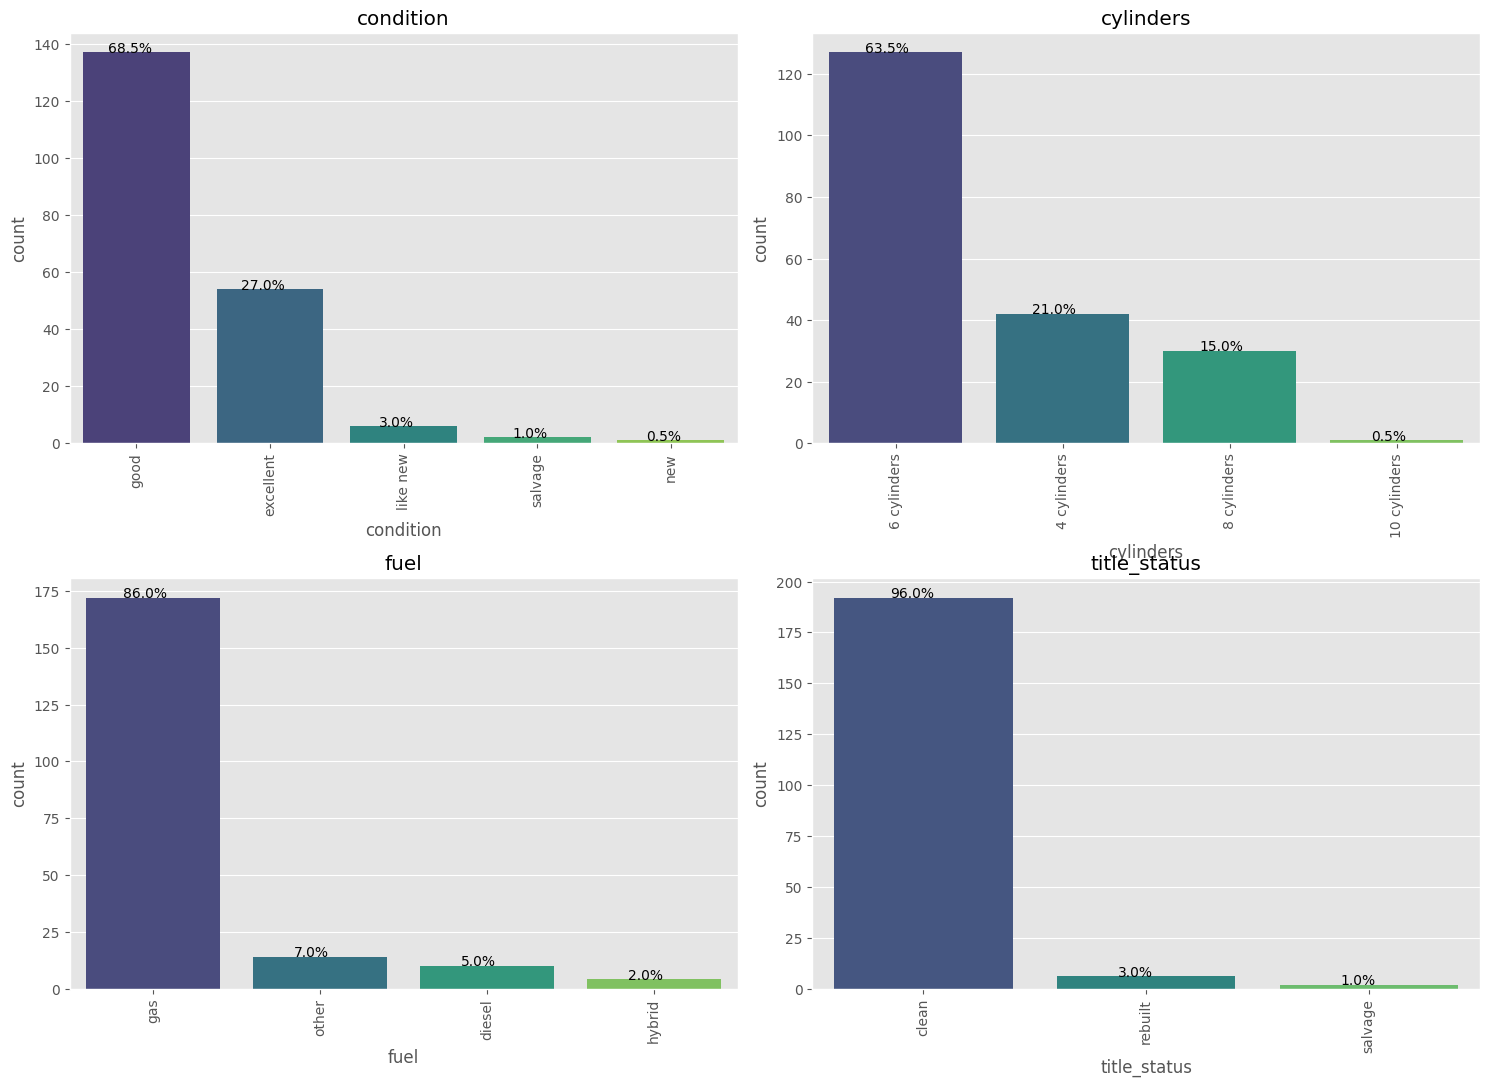

In [31]:
# Plot for all the Categorical Variables

cat_columns=['condition','cylinders','fuel','title_status'] 
plt.figure(figsize=(15,21))

for i, variable in enumerate(cat_columns):
                     plt.subplot(4,2,i+1)
                     order = sample_vehicles5[variable].value_counts(ascending=False).index    
                     ax=sns.countplot(x=sample_vehicles5[variable], data=sample_vehicles5 , order=order ,palette='viridis')
                     for p in ax.patches:
                           percentage = '{:.1f}%'.format(100 * p.get_height()/len(sample_vehicles5[variable]))
                           x = p.get_x() + p.get_width() / 2 - 0.05
                           y = p.get_y() + p.get_height()
                           plt.annotate(percentage, (x, y),ha='center')
                     plt.xticks(rotation=90)
                     plt.tight_layout()
                     plt.title(variable)
    

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Regression is one of the most used types of predictions. We will use Linear regression to address three main questions:

Is there one variable (independent variable) that does a good job of predicting an outcome (dependent variable)? Which variables are the best predictors of the outcome variable? How much do these variables influence the outcome variable (indicated by the magnitude and sign of the beta estimates)?

In [32]:
#Linear Regression Model

vehicles3_sample = vehicles3.sample(2000) 
features = vehicles3_sample[["odometer"]]
prediction = vehicles3_sample["price"]

from sklearn import linear_model
f = linear_model.LinearRegression(fit_intercept = False)
f.fit(features, prediction)

LinearRegression(fit_intercept=False)

In [33]:
# add predictions to dataframe to assess
vehicles3_sample["prediction"] = f.predict(features)
vehicles3_sample.head(5)

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,paint_color,state,prediction
68839,ventura county,29590,2020,infiniti,qx60 pure sport utility,good,6 cylinders,gas,35090,clean,other,SUV,silver,ca,3537.005044
425838,wausau,36990,2018,jeep,wrangler unlimited all new,good,6 cylinders,other,5933,clean,other,other,<NA>,wi,598.035079
163153,sioux city,17000,2019,toyota,corolla,excellent,4 cylinders,gas,24476,clean,other,sedan,<NA>,ia,2467.134097
333776,philadelphia,13990,2010,rover,f-150,excellent,8 cylinders,gas,136000,clean,automatic,<NA>,<NA>,pa,13708.540496
151856,indianapolis,25590,2017,ram,1500 regular cab tradesman,good,6 cylinders,other,27985,clean,other,pickup,<NA>,in,2820.834601


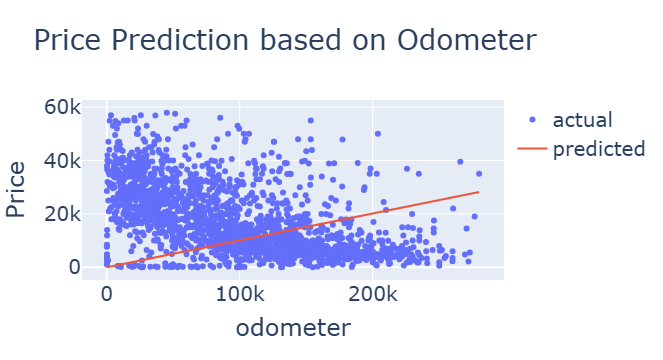

In [62]:
# PLot the prediction
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=vehicles3_sample['odometer'], y = vehicles3_sample['price'], 
                         mode = "markers", name = "actual"))
fig.add_trace(go.Scatter(x=vehicles3_sample['odometer'], y = vehicles3_sample['prediction'], 
                         mode = "lines", name = "predicted"))
fig.update_layout(font_size = 20)

fig.update_layout(
    title='Price Prediction based on Odometer',
    xaxis_title='odometer', 
    yaxis_title='Price', 
    )

In [35]:
#Import the Encoder
!pip install category_encoders

import category_encoders as ce
from category_encoders.james_stein import JamesSteinEncoder

In [36]:
# Build the encoder to transform the data
encoder = ce.JamesSteinEncoder(cols=['manufacturer',  'model', 'condition','cylinders'	,'fuel', 'title_status',	'transmission', 'region','type'  ])

# Encode the frame and view it
vehicle_transformed = encoder.fit_transform(vehicles3, vehicles3['price'])

# View the first few rows
vehicle_transformed.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,type,paint_color,state
27,24306.569978,33590,2014,20592.202279,33968.239572,19153.457467,20935.534315,16905.981207,57923,18186.831336,26842.839283,23828.36751,white,al
28,24306.569978,22590,2010,18479.33359,20643.695509,19153.457467,20935.534315,16905.981207,71229,18186.831336,26842.839283,23828.36751,blue,al
29,24306.569978,39590,2020,18479.33359,31023.167005,19153.457467,20935.534315,16905.981207,19160,18186.831336,26842.839283,23828.36751,red,al
30,24306.569978,30990,2017,17522.433591,33779.829738,19153.457467,20935.534315,16905.981207,41124,18186.831336,26842.839283,23828.36751,red,al
31,24306.569978,15000,2013,18645.890593,19080.54452,15357.74244,18698.960584,16905.981207,128000,18186.831336,16465.927775,21787.196283,black,al


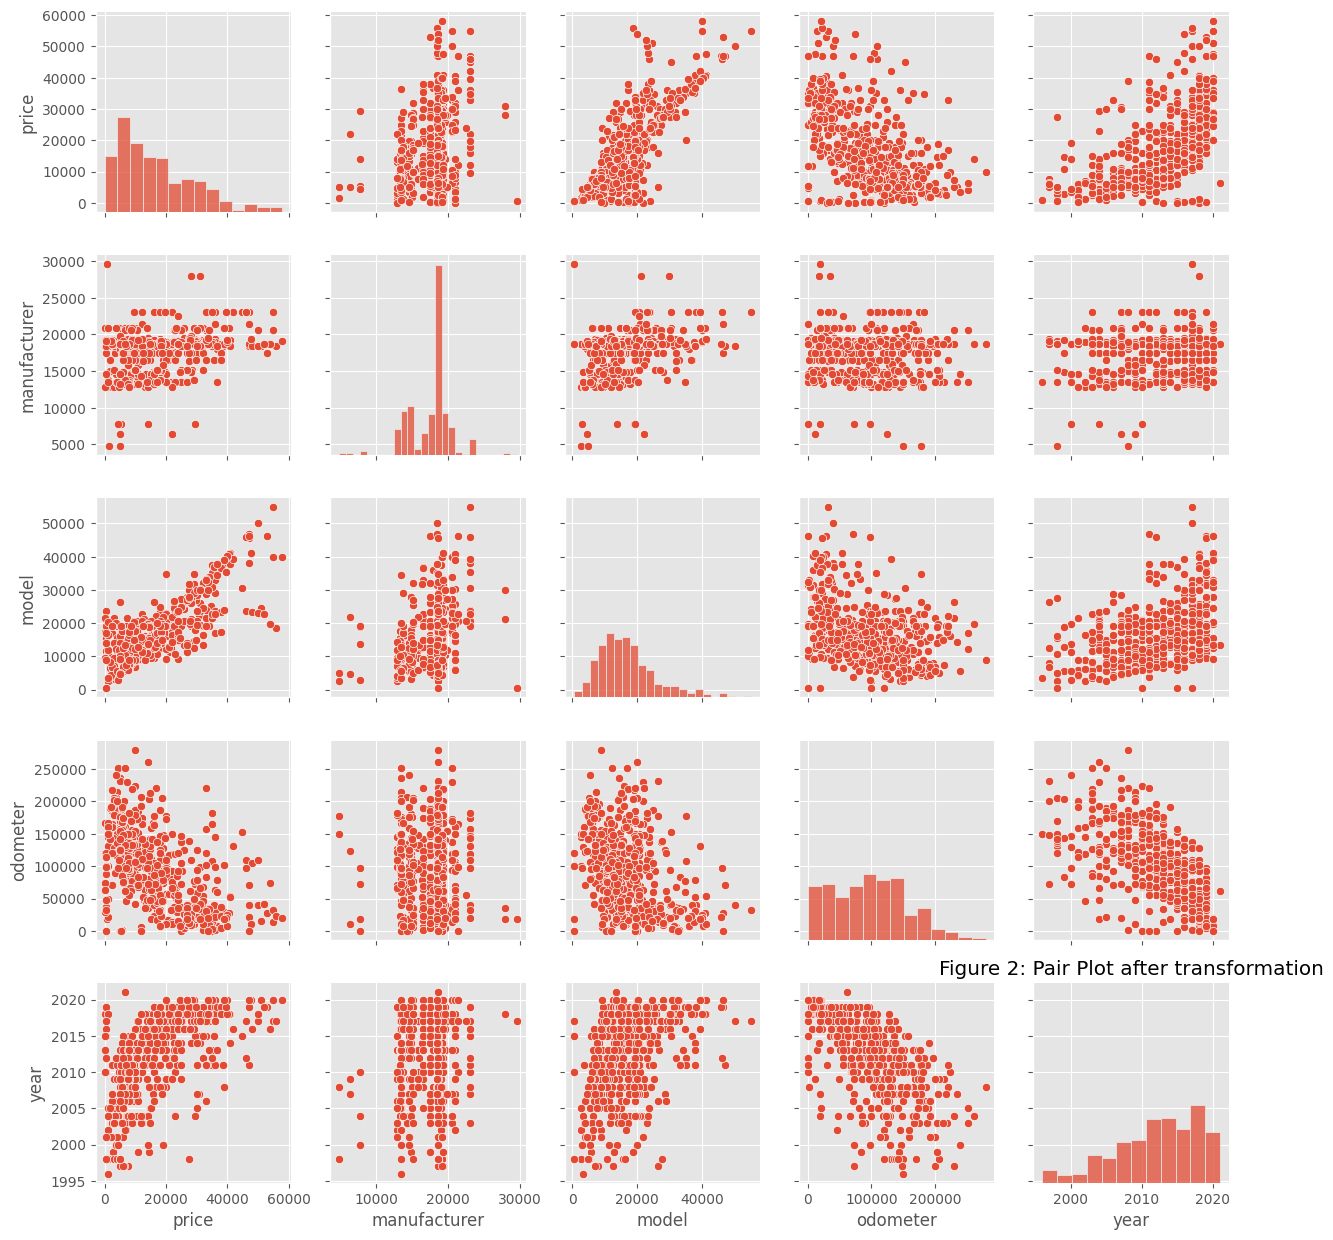

In [37]:
# Verify the plots after data is transformed.
df2=vehicle_transformed.sample(500)
df2.shape

sns.pairplot(data=df2, vars=['price','manufacturer', 'model', 'odometer','year' ])
plt.title('Figure 2: Pair Plot after transformation')
plt.tight_layout()
plt.show()

In [38]:
# Splitting data into test and train datasets.

x = vehicle_transformed.drop('price', axis=1)
X_train, X_test, y_train, y_test = train_test_split(x, np.log1p(vehicle_transformed['price']) ,test_size=0.3, random_state=42)

print(X_train.shape)
print(X_test.shape)
y_train

(252499, 13)
(108214, 13)


21514      9.903037
305432    10.085642
75967      9.420439
424605    10.611302
321913     6.295266
            ...    
143216    10.462846
303922    10.736201
156796     5.298317
173844    10.165506
145689    10.586357
Name: price, Length: 252499, dtype: Float64

In [39]:
#1. Polynomial Features for Feature Expansion
poly_features = PolynomialFeatures(degree=3,include_bias=False)
X_train_poly = poly_features.fit_transform(X_train[['year','odometer', 'model', 'condition', 'title_status' ]])
X_test_poly = poly_features.fit_transform(X_test[['year','odometer', 'model', 'condition',	'title_status' ]])

columns = poly_features.get_feature_names_out()
train_df = pd.DataFrame(X_train_poly, columns=columns)
test_df = pd.DataFrame(X_test_poly, columns=columns)
train_df.head()

,year,odometer,model,condition,title_status,year^2,year odometer,year model,year condition,year title_status,...,model^3,model^2 condition,model^2 title_status,model condition^2,model condition title_status,model title_status^2,condition^3,condition^2 title_status,condition title_status^2,title_status^3
0,2013.0,62039.0,23801.458796,19153.457467,18186.831336,4052169.0,124884507.0,4.791234e+07,3.855591e+07,3.661009e+07,...,1.348375e+13,1.085061e+13,1.030301e+13,8.731683e+12,8.291017e+12,7.872590e+12,7.026540e+12,6.671929e+12,6.335214e+12,6.015492e+12
1,2006.0,102983.0,21487.464727,19153.457467,18186.831336,4024036.0,206583898.0,4.310385e+07,3.842184e+07,3.648278e+07,...,9.921002e+12,8.843365e+12,8.397063e+12,7.882782e+12,7.484959e+12,7.107212e+12,7.026540e+12,6.671929e+12,6.335214e+12,6.015492e+12
2,2013.0,160939.0,12337.000000,19153.457467,18186.831336,4052169.0,323970207.0,2.483438e+07,3.855591e+07,3.661009e+07,...,1.877711e+12,2.915186e+12,2.768064e+12,4.525889e+12,4.297479e+12,4.080596e+12,7.026540e+12,6.671929e+12,6.335214e+12,6.015492e+12
3,2017.0,30011.0,34357.451201,19153.457467,18186.831336,4068289.0,60532187.0,6.929898e+07,3.863252e+07,3.668284e+07,...,4.055672e+13,2.260940e+13,2.146836e+13,1.260420e+13,1.196810e+13,1.136410e+13,7.026540e+12,6.671929e+12,6.335214e+12,6.015492e+12
4,2020.0,14501.0,520.520467,15357.742440,18186.831336,4080400.0,29292020.0,1.051451e+06,3.102264e+07,3.673740e+07,...,1.410306e+08,4.161051e+09,4.927568e+09,1.227701e+11,1.453859e+11,1.721678e+11,3.622281e+12,4.289551e+12,5.079740e+12,6.015492e+12


In [40]:
#2. Baseline prediction
baseline_pred = y_train.mean()
baseline_rmse = np.sqrt(mean_squared_error(y_test, [baseline_pred] * len(y_test)))
print(f"Baseline RMSE: {baseline_rmse}")

Baseline RMSE: 1.1740841881580275


In [41]:
#3. SequentialFeatureSelector to select the important features
selector = SequentialFeatureSelector(LinearRegression(),n_features_to_select=5)
best_features = selector.fit_transform(train_df, y_train)
best_features_df = pd.DataFrame(best_features, columns=selector.get_feature_names_out())

best_features_df.head()

,year^2,odometer^2,year model condition,model^2 condition,model condition^2
0,4052169.0,3.848838e+09,9.176869e+11,1.085061e+13,8.731683e+12
1,4024036.0,1.060550e+10,8.255878e+11,8.843365e+12,7.882782e+12
2,4052169.0,2.590136e+10,4.756643e+11,2.915186e+12,4.525889e+12
3,4068289.0,9.006601e+08,1.327315e+12,2.260940e+13,1.260420e+13
4,4080400.0,2.102790e+08,1.614792e+10,4.161051e+09,1.227701e+11


In [42]:
# 4. Setup regression using pipeline and Make predictions on the test set with the best features selected
pipe = Pipeline([('column_selector',selector),('lin', LinearRegression())])

# Fit pipeline to training data
pipe.fit(train_df, y_train)

# Make predictions on train and test sets
train_preds = pipe.predict(train_df)
test_preds = pipe.predict(test_df)

# Evaluate performance using MSE and RMSE
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)

train_rmse = sqrt(train_mse)
test_rmse = sqrt(test_mse)

# Print results
print(f'Train MSE: {train_mse:.2f}')
print(f'Test MSE: {test_mse:.2f}')
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

# Evaluate R² Score
train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print(f'Train R² Score: {train_r2:.2f}')
print(f'Test R² Score: {test_r2:.2f}')

Train MSE: 0.87
Test MSE: 0.84
Train RMSE: 0.94
Test RMSE: 0.92
Train R² Score: 0.37
Test R² Score: 0.39


The MSE is slightly lower on the test set, which is a good sign. It suggests that the model is not overfitting. The RMSE values based on the predictions are off by about 0.92-0.94 units.


In [43]:
# Cross Validation and try other model for better results

In [44]:
#Random Forest to capture non-linear relationships between features
from sklearn.ensemble import RandomForestRegressor
RFR = RandomForestRegressor(n_estimators=180,random_state=0, min_samples_leaf=1, max_features=0.5, n_jobs=-1, oob_score=True)
RFR.fit(train_df,y_train)

RandomForestRegressor(max_features=0.5, n_estimators=180, n_jobs=-1,
                      oob_score=True, random_state=0)

In [45]:
# Run the model and print the MSEs
train_preds = RFR.predict(train_df)
test_preds = RFR.predict(test_df)
train_mse = mean_squared_error(train_preds, y_train)
test_mse = mean_squared_error(test_preds, y_test)

print(f'Train MSE: {train_mse: .2f}')
print(f'Test MSE: {test_mse: .2f}')

Train MSE:  0.09
Test MSE:  0.40


In [46]:
# 5. Cross validate the results with this new model - calculate the MSE

In [47]:
# Create DataFrames
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results_df = pd.DataFrame({'Actual': y_train, 'Predicted': train_preds})
results_ldf = pd.DataFrame({'Actual': np.expm1(y_train), 'Predicted': np.expm1(train_preds)})

# Display first few rows
print("Log Scale Results:")
print(results_df.head())

print("\nOriginal Scale Results:")
print(results_ldf.head())

# Calculate error metrics for both scales
def print_metrics(y_true, y_pred, scale):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nMetrics ({scale} scale):")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

print_metrics(results_df['Actual'], results_df['Predicted'], "Log")
print_metrics(results_ldf['Actual'], results_ldf['Predicted'], "Original")

Log Scale Results:
           Actual  Predicted
21514    9.903037   9.903037
305432  10.085642  10.084007
75967    9.420439   9.221679
424605  10.611302  10.611302
321913   6.295266   6.283372

Original Scale Results:
         Actual     Predicted
21514   19990.0  19990.000000
305432  23995.0  23955.789020
75967   12337.0  10113.035209
424605  40590.0  40590.000000
321913    541.0    534.591626

Metrics (Log scale):
MSE: 0.0890
RMSE: 0.2982
MAE: 0.0967
R2 Score: 0.9364

Metrics (Original scale):
MSE: 5228942.7142
RMSE: 2286.6882
MAE: 919.6266
R2 Score: 0.9679


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

1. Executive Summary
In this report, we provide data-driven insights that can help used car dealers optimize their inventory selection and pricing strategies. By analyzing key variables such as car make, model, odometer, condition, and price, we uncover trends that will allow you to make informed decisions to meet customer expectation and maximize profitability.

2. Objective
The primary goal of this analysis is to help your business:

a. Set competitive prices that attract buyers 
b. Leverage key data patterns to make informed business decisions

3. Methodology
To derive actionable insights, we analyzed historical data from used car sales, including variables like:

a. Car Make and Model
b. Odometer
c. Year of Manufacture
c. Price
d. Condition
e. Make

Our approach involved several data analysis techniques, including:

a. Exploratory Data Analysis (EDA): To identify trends, correlations, and outliers.
b. Price Analysis: To establish pricing patterns based on car attributes.
c. Price Forecasting: To predict the price for most in-demand makes and models

4. Key Findings
Several key factor influence the price of the car. Our findings indicate that from a customer's point of view typically they value the odometer reading, year, model, and condition of the car to agree to a price point for buying a car.

6. Conclusion
By utilizing the insights gained from this analysis, used car dealers can strategically adjust the inventory, set optimal prices, and better meet customer demand. The key is to stay agile and monitor trends to fine-tune your offerings continuously